# Size-Effect -- do small-caps really beat large-caps?
### Banz (1981), the original cross-sectional anomaly, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![January concentration%3F: Busted](https://img.shields.io/badge/January--concentration%3F-Busted-8b949e?style=flat-square)

In 1981 Rolf Banz noticed something the CAPM could not explain: **small companies earned higher returns than big ones**, even after adjusting for risk. It became the founding anomaly of factor investing -- Fama and French later packaged it as **SMB (Small Minus Big)**, one of their three factors. The premium was famously concentrated in **January**.

We test that claim on a 40-name basket spanning mega-caps (Apple, Microsoft) down to genuine small/mid-caps (Sensient, WD-40, J&J Snack...), ranking by market cap each month, buying the small half and shorting the big half -- naming the survivorship bias up front.

> **This is the plain-language layer.** Want the cap-ranking mechanics, the label-shuffle placebo and the decay slice? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from size_effect import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    c = os.path.join(study, "_cache")
    return all(os.path.exists(os.path.join(c, f)) for f in
               ("size_prices.parquet", "size_spy.parquet", "size_caps.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy, caps = data.fetch_panel()
    book = st.add_beta_neutral(st.smb_portfolio(prices, spy, caps, min_stocks=10))
    book = data.drop_partial_last_month(book)
    s_dn = st.summary(book["smb_dn"]); s_bn = st.summary(book["smb_bn"])
    print(f"N months: {s_dn['n']} | SMB dollar-neutral: {s_dn['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_dn['tstat']:+.3f}")


yfinance cache present: True


N months: 304 | SMB dollar-neutral: -1.08%/yr | HAC t: -0.483


## The answer first

| Question | Answer |
|---|---|
| Do small-caps beat big-caps? | **No, the reverse.** The small-minus-large book earns **-1.08%/yr** at HAC *t* = **-0.48** -- wrong sign, statistically zero. |
| Can a coin-flip beat it? | **Yes.** A label-shuffle placebo reproduces the real *t* **61%** of the time (*p* = 0.61). |
| Is there a January pop? | **Busted.** January was the *worst* month for the spread (**-1.01%/mo** vs ~0 the rest of the year). |
| Survivorship problem? | **Yes, named.** Failed small-caps -- the natural long -- are gone, biasing the premium *up*; it is *still* negative. |

> Banz's size effect is real in the 1936-1975 broad-universe literature, but on this survivor basket over the mega-cap decade 2001-2026 it has vanished and inverted.

## First, prove the engine works -- a synthetic world with a *real* size premium

Before trusting a flat real-tape result, we plant a known 6%/yr small-cap premium in a fake market and check the **same sort/long-short/t-stat pipeline** finds it. We average over 25 random seeds so no single lucky draw can carry the claim.

In [2]:
sc = st.synthetic_control(size_premium=0.06, n_seeds=25)
print(f"Planted 6%/yr premium -> mean HAC t = {sc['mean_t_signal']:+.2f} "
      f"(t>2 in {sc['frac_signal_t_gt2']*100:.0f}% of seeds)")
print(f"Null (0% premium)      -> mean HAC t = {sc['mean_t_null']:+.2f} "
      f"(|t|>2 in {sc['frac_null_t_gt2']*100:.0f}% of seeds)")
print('\nThe engine recovers a real premium and stays quiet under the null:'
      ' the flat REAL result is about the data, not a broken harness.')

Planted 6%/yr premium -> mean HAC t = +2.73 (t>2 in 72% of seeds)
Null (0% premium)      -> mean HAC t = +0.81 (|t|>2 in 8% of seeds)

The engine recovers a real premium and stays quiet under the null: the flat REAL result is about the data, not a broken harness.


## The real basket -- small vs big, 2001-2026

Small-caps did *not* win. Over this large-cap decade the big half out-earned the small half on both return and Sharpe.

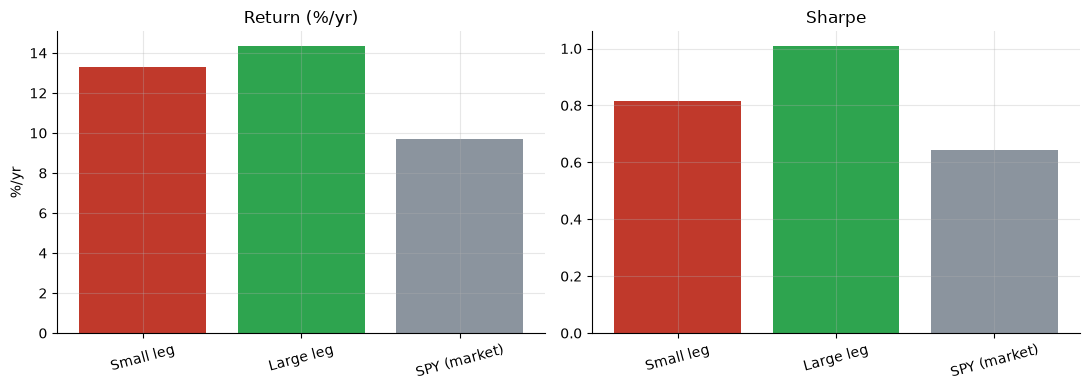

Small +13.3%/yr (Sharpe +0.81) vs Large +14.4%/yr (Sharpe +1.01) -- big won.


In [3]:
if HAVE_REAL:
    s_small = st.summary(book['small_ret']); s_large = st.summary(book['large_ret'])
    s_mkt = st.summary(book['mkt_ret'])
    labels = ['Small leg', 'Large leg', 'SPY (market)']
    means = [s_small['mean']*100, s_large['mean']*100, s_mkt['mean']*100]
    shps  = [s_small['sharpe'], s_large['sharpe'], s_mkt['sharpe']]
else:
    labels = ['Small leg', 'Large leg', 'SPY (market)']
    means = [R['small_mean'], R['large_mean'], R['mkt_mean']]
    shps  = [R['small_sharpe'], R['large_sharpe'], R['mkt_sharpe']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
cols = [RED, GREEN, GREY]
a1.bar(labels, means, color=cols); a1.set_title('Return (%/yr)'); a1.set_ylabel('%/yr')
a2.bar(labels, shps, color=cols); a2.set_title('Sharpe')
for ax in (a1, a2):
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print(f'Small {means[0]:+.1f}%/yr (Sharpe {shps[0]:+.2f}) vs '
      f'Large {means[1]:+.1f}%/yr (Sharpe {shps[1]:+.2f}) -- big won.')

## The January pop -- busted

Banz's premium classically showed up in **January** (tax-loss rebound). Here January was the spread's *worst* month.

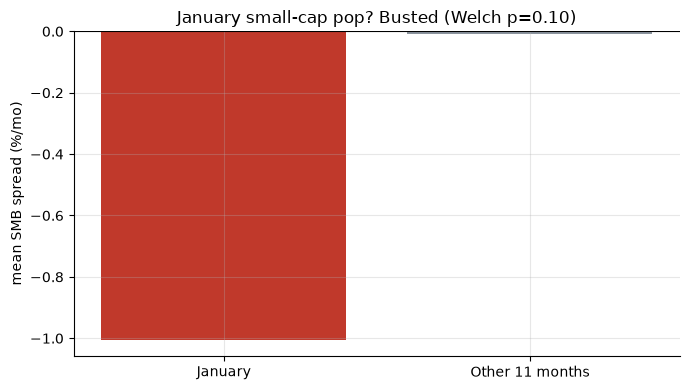

January -1.01%/mo vs other months -0.01%/mo -- the wrong way round.


In [4]:
if HAVE_REAL:
    jan = st.january_split(book)
    jm, rm, wp = jan['jan_mean']*100, jan['rest_mean']*100, jan['welch_p']
else:
    jm, rm, wp = R['jan_mean'], R['rest_mean'], R['jan_welch_p']
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['January', 'Other 11 months'], [jm, rm], color=[RED, GREY])
ax.axhline(0, c='k', lw=0.8); ax.set_ylabel('mean SMB spread (%/mo)')
ax.set_title(f'January small-cap pop? Busted (Welch p={wp:.2f})')
plt.tight_layout(); plt.show()
print(f'January {jm:+.2f}%/mo vs other months {rm:+.2f}%/mo -- the wrong way round.')

## The honest verdict

- **Signal -- NONE.** SMB = -1.08%/yr, HAC *t* = -0.48, placebo *p* = 0.61. Wrong sign, statistically zero.
- **Tradability -- MIRAGE.** Net of a -2.08%/yr book after short borrow -- nothing to trade.
- **January concentration? -- BUSTED.** The signature January pop is absent and reversed.
- **Survivorship -- Named.** Failed small-caps are gone, biasing the premium up; it is *still* negative.

Banz (1981) is a genuine historical finding on a broad 1936-1975 universe. On a small survivor basket over the mega-cap-led 2001-2026 era, replicated honestly with real costs, the size premium simply isn't there -- the expected, on-brand outcome for a pointed academic factor.